## Khám phá dữ liệu (EDA) trước khi tiền xử lý

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

csv_file = "../data/raw/Online Retail.csv"
df = pd.read_csv(csv_file, encoding="utf-8-sig")

# Parse InvoiceDate ngay từ đầu; errors='coerce' để tránh crash nếu có ngày lỗi định dạng
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print(f"Kích thước dữ liệu gốc: {df.shape}")
df.head()

Kích thước dữ liệu gốc: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Ý NGHĨA CÁC CỘT
InvoiceNo: id hóa đơn

StockCode: id của món hàng

Description: Tên món hàng

Quantity: số lượng

Invoice Date: Ngày mua

UnitPrice: đơn giá

CustomerID: ID khách hàng

Country: Quốc gia của khách hàng


In [2]:
print("Thông tin tổng quan về dữ liệu:")
df.info()
print()
print("Thống kê mô tả các cột số:")
df.describe()

Thông tin tổng quan về dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB

Thống kê mô tả các cột số:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [3]:
print("Tỷ lệ giá trị thiếu theo từng cột:")
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_pct[missing_pct > 0])
if missing_pct.sum() == 0:
    print("-> Không có cột nào bị thiếu dữ liệu.")

Tỷ lệ giá trị thiếu theo từng cột:
Description     0.27
CustomerID     24.93
dtype: float64


### Phân phối Quantity và UnitPrice 

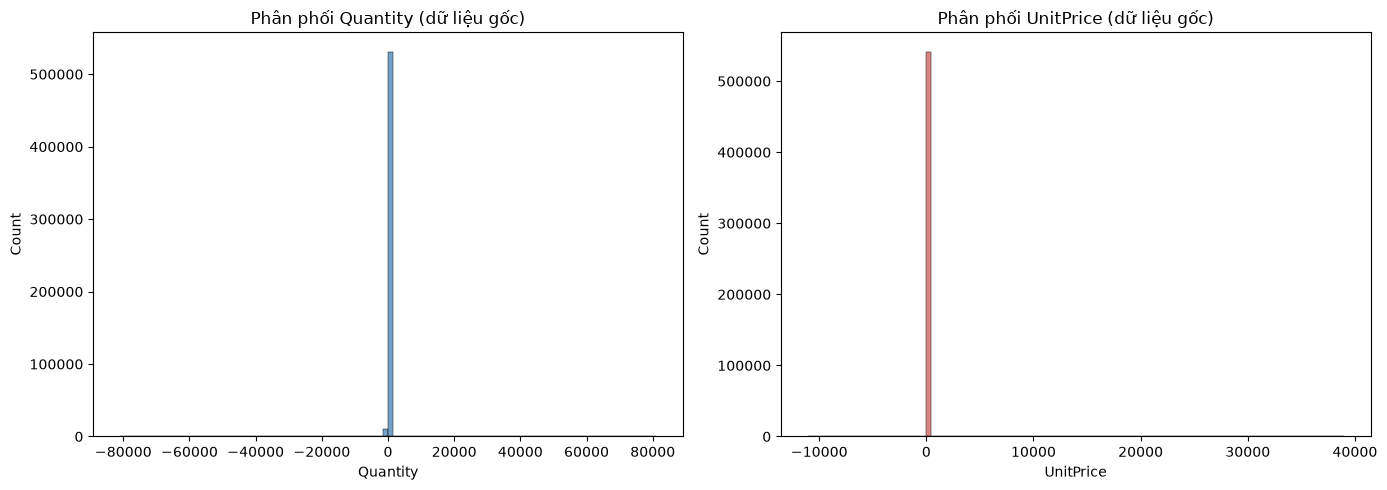

Số dòng Quantity <= 0: 10,624
Số dòng UnitPrice <= 0: 2,517


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Quantity'], bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('Phân phối Quantity (dữ liệu gốc)')
axes[0].set_xlabel('Quantity')

sns.histplot(df['UnitPrice'], bins=100, ax=axes[1], color='indianred')
axes[1].set_title('Phân phối UnitPrice (dữ liệu gốc)')
axes[1].set_xlabel('UnitPrice')

plt.tight_layout()
plt.show()

print(f"Số dòng Quantity <= 0: {(df['Quantity'] <= 0).sum():,}")
print(f"Số dòng UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum():,}")

In [5]:
# Xem 10 dòng có Quantity cực đoan nhất (cả 2 chiều dương/âm)
print("Quantity cực đoan:")
print(df.nlargest(10, 'Quantity')[['InvoiceNo','Description','Quantity','UnitPrice','CustomerID']])
print(df.nsmallest(10, 'Quantity')[['InvoiceNo','Description','Quantity','UnitPrice','CustomerID']])

print("\nUnitPrice cực đoan:")
print(df.nlargest(10, 'UnitPrice')[['InvoiceNo','Description','Quantity','UnitPrice','CustomerID']])

Quantity cực đoan:
       InvoiceNo                          Description  Quantity  UnitPrice  \
540421    581483          PAPER CRAFT , LITTLE BIRDIE     80995       2.08   
61619     541431       MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04   
502122    578841       ASSTD DESIGN 3D PAPER STICKERS     12540       0.00   
74614     542504                                  NaN      5568       0.00   
421632    573008    WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800       0.21   
206121    554868                 SMALL POPCORN HOLDER      4300       0.72   
220843    556231                                    ?      4000       0.00   
97432     544612                EMPIRE DESIGN ROSETTE      3906       0.82   
270885    560599  ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186       0.06   
52711     540815   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114       2.10   

        CustomerID  
540421     16446.0  
61619      12346.0  
502122     13256.0  
74614          NaN  
421632     12901.

### Top 10 quốc gia theo số lượng giao dịch

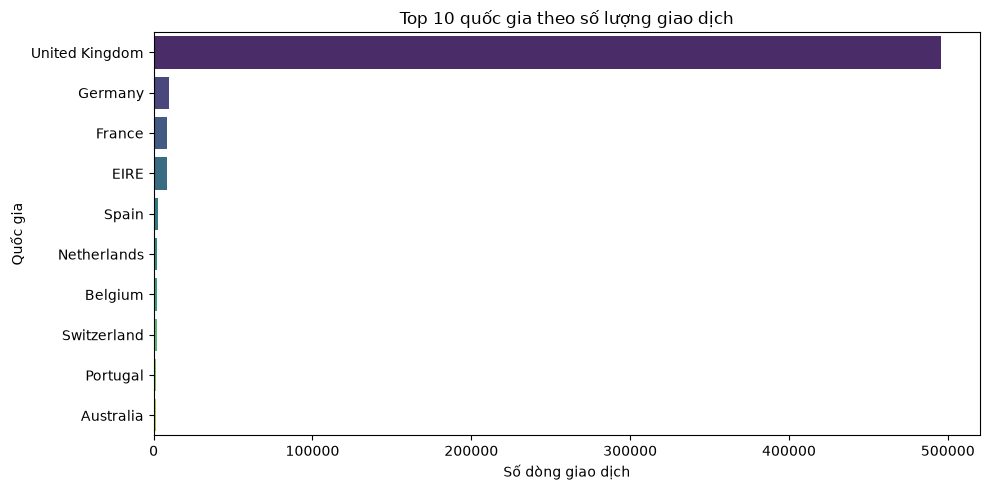

In [6]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 quốc gia theo số lượng giao dịch')
plt.xlabel('Số dòng giao dịch')
plt.ylabel('Quốc gia')
plt.tight_layout()
plt.show()

### Xu hướng số lượng giao dịch theo thời gian

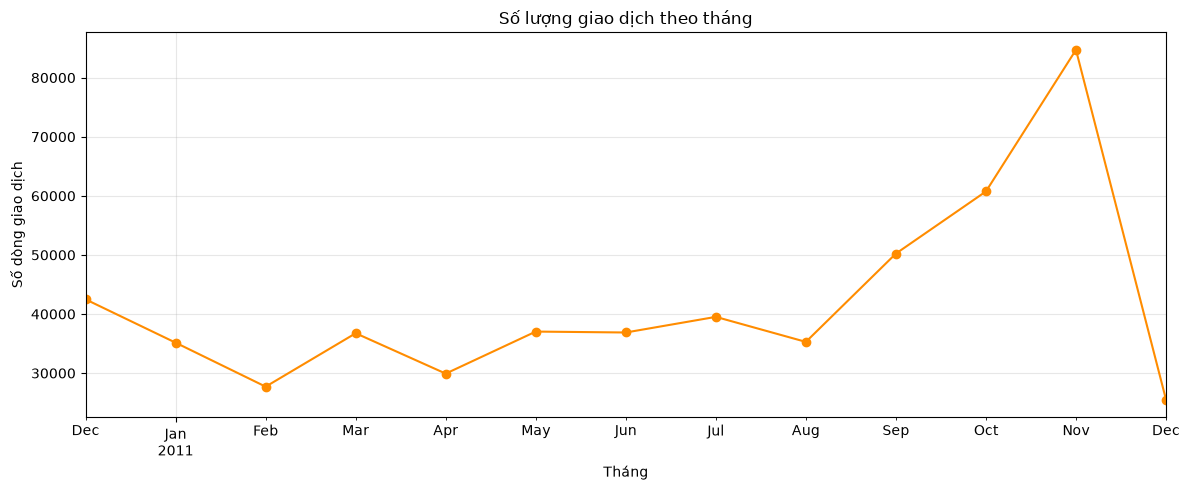

In [7]:
df_time = df.dropna(subset=['InvoiceDate']).copy()
monthly_transactions = df_time.set_index('InvoiceDate').resample('ME').size()

plt.figure(figsize=(12, 5))
monthly_transactions.plot(marker='o', color='darkorange')
plt.title('Số lượng giao dịch theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Số dòng giao dịch')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Top 10 sản phẩm bán chạy nhất theo tổng số lượng

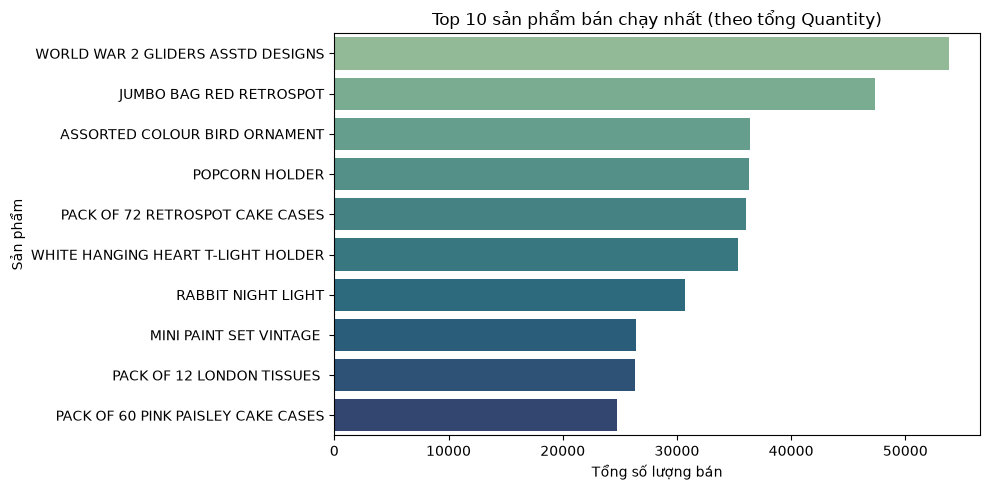

In [8]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='crest', legend=False)
plt.title('Top 10 sản phẩm bán chạy nhất (theo tổng Quantity)')
plt.xlabel('Tổng số lượng bán')
plt.ylabel('Sản phẩm')
plt.tight_layout()
plt.show()

# Phân khúc khách hàng — Tiền xử lý dữ liệu RFM

**Pipeline:**

```
Raw Data
  -> Remove Quantity<=0
  -> Remove UnitPrice<=0
  -> Remove Null CustomerID
  -> Remove Duplicate
  -> TotalPrice (feature)
  -> RFM
  -> Remove Outlier
  -> Log Transform
  -> StandardScaler
  
```

## Bước 1: Remove Quantity <= 0

In [9]:
before = df.shape[0]
df = df[df['Quantity'] > 0]
print(f"[Bước 1] Loại Quantity <= 0: xóa {before - df.shape[0]:,} dòng -> còn {df.shape[0]:,} dòng")

[Bước 1] Loại Quantity <= 0: xóa 10,624 dòng -> còn 531,285 dòng


## Bước 2: Remove UnitPrice <= 0

In [10]:
before = df.shape[0]
df = df[df['UnitPrice'] > 0]
print(f"[Bước 2] Loại UnitPrice <= 0: xóa {before - df.shape[0]:,} dòng -> còn {df.shape[0]:,} dòng")

[Bước 2] Loại UnitPrice <= 0: xóa 1,181 dòng -> còn 530,104 dòng


## Bước 3: Remove Null CustomerID

In [11]:
before = df.shape[0]
# Loại luôn cả InvoiceDate bị lỗi định dạng (NaT) cùng lúc vì cả 2 đều là trường bắt buộc cho RFM
df = df.dropna(subset=['CustomerID', 'InvoiceDate'])
print(f"[Bước 3] Loại CustomerID rỗng / InvoiceDate lỗi: xóa {before - df.shape[0]:,} dòng -> còn {df.shape[0]:,} dòng")

df['CustomerID'] = df['CustomerID'].astype(int)

[Bước 3] Loại CustomerID rỗng / InvoiceDate lỗi: xóa 132,220 dòng -> còn 397,884 dòng


## Bước 4: Remove Duplicate

**Lưu ý quan trọng:** dedup được thực hiện ở đây, khi `StockCode`/`Description` **vẫn còn nguyên** trong dữ liệu (chưa bị drop). Nếu dedup sau khi đã mất 2 cột này, hai dòng khác **sản phẩm** nhưng trùng InvoiceNo/Quantity/UnitPrice/InvoiceDate sẽ bị nhầm là trùng lặp và bị xóa oan, làm sai lệch Frequency/Monetary.

In [12]:
before = df.shape[0]
df = df.drop_duplicates()
print(f"[Bước 4] Loại dòng trùng lặp hoàn toàn: xóa {before - df.shape[0]:,} dòng -> còn {df.shape[0]:,} dòng")

[Bước 4] Loại dòng trùng lặp hoàn toàn: xóa 5,192 dòng -> còn 392,692 dòng


## Bước 5: TotalPrice (feature)

In [13]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalPrice']].head()

,InvoiceNo,Quantity,UnitPrice,TotalPrice
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


## Bước 6: Tính RFM

In [14]:
snapshot_date = df['InvoiceDate'].max()
print(f"Ngày mốc tính Recency: {snapshot_date}")

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print(f"Tổng số khách hàng: {rfm.shape[0]}")
rfm.describe()

Ngày mốc tính Recency: 2011-12-09 12:50:00
Tổng số khách hàng: 4338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,91.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,0.000000,1.000000,3.750000
25%,13813.250000,17.000000,1.000000,306.482500
50%,15299.500000,50.000000,2.000000,668.570000
75%,16778.750000,141.000000,5.000000,1660.597500
max,18287.000000,373.000000,209.000000,280206.020000


In [15]:
# Lưu TOÀN BỘ RFM (bao gồm cả khách hàng sẽ bị coi là outlier ở bước sau)
# File này dùng ở train.ipynb để dự đoán cụm cho TẤT CẢ khách hàng, kể cả outlier -
# outlier chỉ nên bị loại khi HUẤN LUYỆN mô hình, không được loại khỏi kết quả đầu ra cuối cùng.
full_rfm_path = '../data/processed/customer_segmentation_full.csv'
os.makedirs(os.path.dirname(full_rfm_path), exist_ok=True)
rfm.to_csv(full_rfm_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu RFM đầy đủ (chưa loại outlier) tại: {full_rfm_path}")

Đã lưu RFM đầy đủ (chưa loại outlier) tại: ../data/processed/customer_segmentation_full.csv


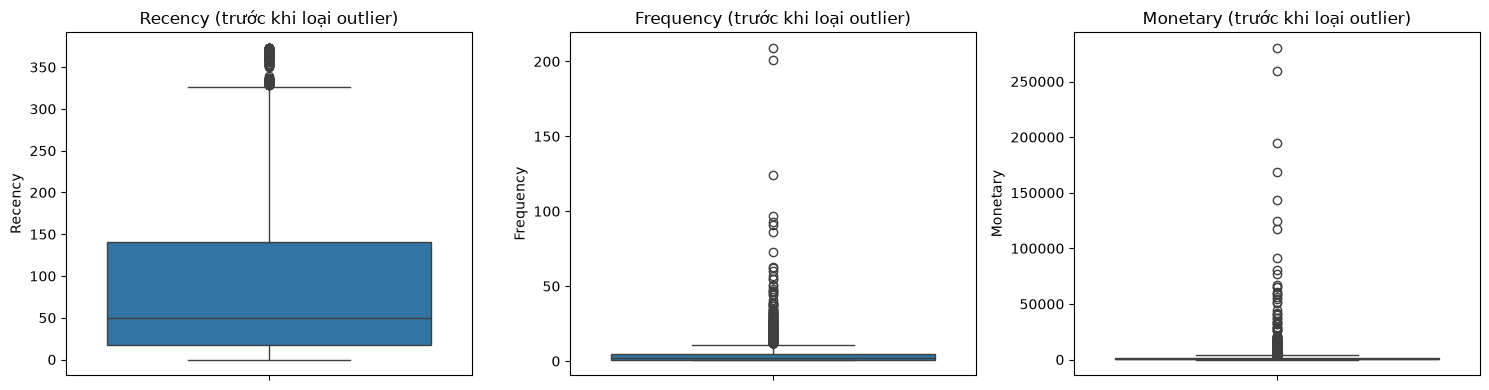

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm[col], ax=ax)
    ax.set_title(f'{col} (trước khi loại outlier)')
plt.tight_layout()
plt.show()

## Bước 7: Remove Outlier

Dùng phương pháp **IQR** (Interquartile Range) trên cả 3 đặc trưng R, F, M — loại các khách hàng có giá trị nằm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`. Đây là các khách hàng cực đoan (ví dụ mua sỉ số lượng cực lớn) có thể kéo lệch tâm cụm nếu giữ lại.

In [17]:
def remove_outliers_iqr(data, cols, factor=1.5):
    mask = pd.Series(True, index=data.index)
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        mask &= data[col].between(lower, upper)
    return data[mask], mask

before = rfm.shape[0]
rfm, outlier_mask = remove_outliers_iqr(rfm, ['Recency', 'Frequency', 'Monetary'], factor=1.5)
rfm = rfm.reset_index(drop=True)
print(f"[Bước 7] Loại outlier (IQR, factor=1.5): xóa {before - rfm.shape[0]:,} khách hàng -> còn {rfm.shape[0]:,} khách hàng")

[Bước 7] Loại outlier (IQR, factor=1.5): xóa 628 khách hàng -> còn 3,710 khách hàng


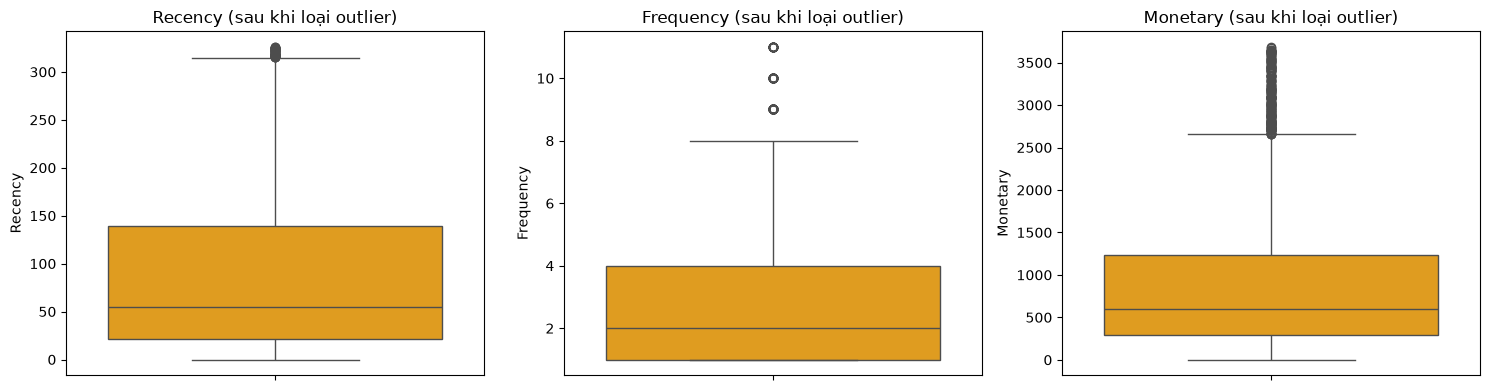

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm[col], ax=ax, color='orange')
    ax.set_title(f'{col} (sau khi loại outlier)')
plt.tight_layout()
plt.show()

In [19]:
# Lưu bảng RFM (đã loại outlier, đơn vị gốc) để dùng cho business profiling ở train.ipynb
raw_rfm_path = '../data/processed/customer_segmentation.csv'
os.makedirs(os.path.dirname(raw_rfm_path), exist_ok=True)
rfm.to_csv(raw_rfm_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu bảng RFM tại: {raw_rfm_path}")

Đã lưu bảng RFM tại: ../data/processed/customer_segmentation.csv


## Bước 8: Log Transform

Frequency và Monetary vẫn còn lệch phải sau khi loại outlier -> dùng `log1p` để đưa phân phối gần chuẩn hơn, giúp K-Means/Hierarchical (dựa trên khoảng cách Euclidean) hoạt động hiệu quả hơn.

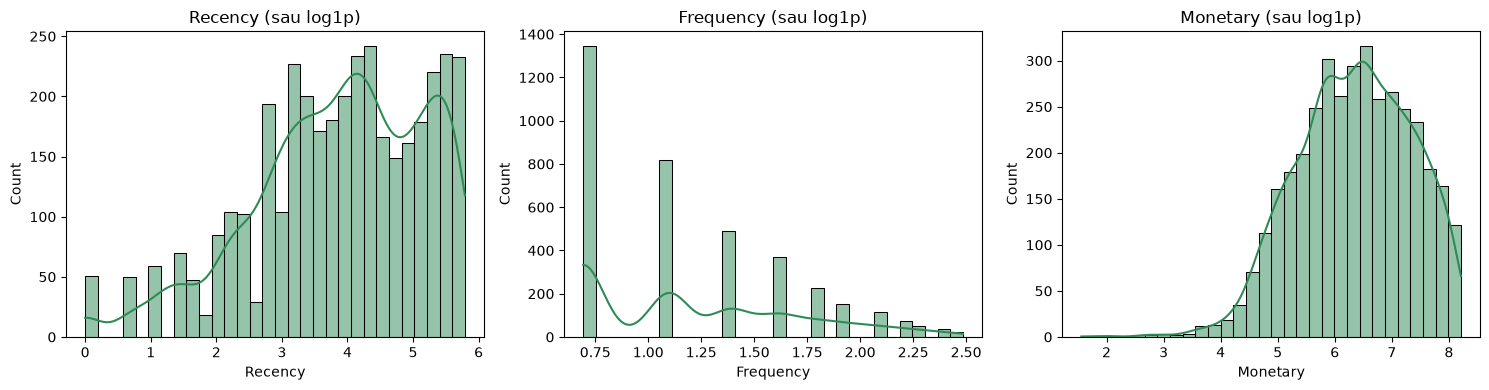

In [20]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm_log[col], bins=30, kde=True, ax=ax, color='seagreen')
    ax.set_title(f'{col} (sau log1p)')
plt.tight_layout()
plt.show()

## Bước 9: StandardScaler

In [21]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled_array, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.insert(0, 'CustomerID', rfm['CustomerID'].values)

os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/rfm_scaler.pkl')

output_data_path = "../data/processed/customer_segmentation_scaled.csv"
rfm_scaled_df.to_csv(output_data_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu dữ liệu chuẩn hóa tại: {output_data_path}")
rfm_scaled_df.head()

Đã lưu dữ liệu chuẩn hóa tại: ../data/processed/customer_segmentation_scaled.csv


,CustomerID,Recency,Frequency,Monetary
0,12348,0.345808,0.802046,1.150439
1,12349,-0.704335,-1.038172,1.128021
2,12350,1.431159,-1.038172,-0.536308
3,12352,-0.215550,1.982518,1.484219
4,12353,1.111116,-1.038172,-1.857703


## Kết luận

Pipeline hoàn chỉnh: Raw Data -> lọc Quantity/UnitPrice/CustomerID -> Remove Duplicate -> TotalPrice -> RFM -> Remove Outlier (IQR) -> Log Transform -> StandardScaler

**Output:**
- `customer_segmentation.csv`: RFM đơn vị gốc, đã loại outlier — dùng để diễn giải cụm (business profiling)
- `customer_segmentation_scaled.csv`: RFM đã log-transform + scale (3 chiều) — dùng để huấn luyện K-Means/Hierarchical/DBSCAN

